# Backward induction with deadline T_max

In [3]:
import numpy as np

def solve_dp_discrete_evidence(P_x_H1, P_x_H2, cost, T_max, num_belief_bins=500):
    """
    Solves the optimal stopping policy for discrete, heterogeneous evidence.
    
    P_x_H1: Array of probabilities of observing each x given H1
    P_x_H2: Array of probabilities of observing each x given H2
    cost: Cost per sample
    T_max: Maximum time steps (deadline)
    """
    
    # 1. Set up the Belief Space
    beliefs = np.linspace(0, 1, num_belief_bins)
    
    # 2. Initialize the Value matrix V(b, t)
    # Shape: (num_belief_bins, T_max + 1)
    V = np.zeros((num_belief_bins, T_max + 1))
    
    # Value of stopping is independent of time
    V_stop = np.maximum(beliefs, 1 - beliefs)
    
    # Base case: At the deadline T_max, the agent MUST stop.
    V[:, T_max] = V_stop
    
    # Keep track of the decision boundaries
    # Tuple of (lower_bound, upper_bound) for each t
    boundaries = []
    
    # 3. Backward Induction
    for t in range(T_max - 1, -1, -1):
        V_wait = np.zeros(num_belief_bins)
        
        for i, b in enumerate(beliefs):
            # Calculate marginal probability of each observation given current belief
            P_x_given_b = b * P_x_H1 + (1 - b) * P_x_H2
            
            # Calculate updated posterior belief for each possible observation
            # (Adding a tiny epsilon to avoid division by zero)
            b_next = (P_x_H1 * b) / (P_x_given_b + 1e-12)
            
            # Find the closest bin index in our discretized belief space for b_next
            b_next_idx = np.clip(np.round(b_next * (num_belief_bins - 1)), 0, num_belief_bins - 1).astype(int)
            
            # Expected value of tomorrow
            expected_future_value = np.sum(P_x_given_b * V[b_next_idx, t + 1])
            
            # Value of waiting today
            V_wait[i] = expected_future_value - cost
            
        # The Bellman optimal value today
        V[:, t] = np.maximum(V_stop, V_wait)
        
        # 4. Find the Boundaries
        # The boundary is where V_stop >= V_wait
        stop_action = V_stop >= V_wait
        
        # Find the lower bound (largest belief < 0.5 where we stop)
        lower_candidates = beliefs[(stop_action) & (beliefs <= 0.5)]
        lower_bound = np.max(lower_candidates) if len(lower_candidates) > 0 else 0.0
        
        # Find the upper bound (smallest belief > 0.5 where we stop)
        upper_candidates = beliefs[(stop_action) & (beliefs >= 0.5)]
        upper_bound = np.min(upper_candidates) if len(upper_candidates) > 0 else 1.0
        
        boundaries.insert(0, (lower_bound, upper_bound))
        
    return V, boundaries

# --- Example Execution ---
# Let's create a simplified synthetic heterogeneous environment (e.g., 3 possible stimuli)
# x1: Strongly supports H1
# x2: Ambiguous / Noisy
# x3: Strongly supports H2
P_x_H1 = np.array([0.7, 0.2, 0.1])
P_x_H2 = np.array([0.1, 0.2, 0.7])
cost = 0.01
T_max = 15

V_optimal, bounds = solve_dp_discrete_evidence(P_x_H1, P_x_H2, cost, T_max)

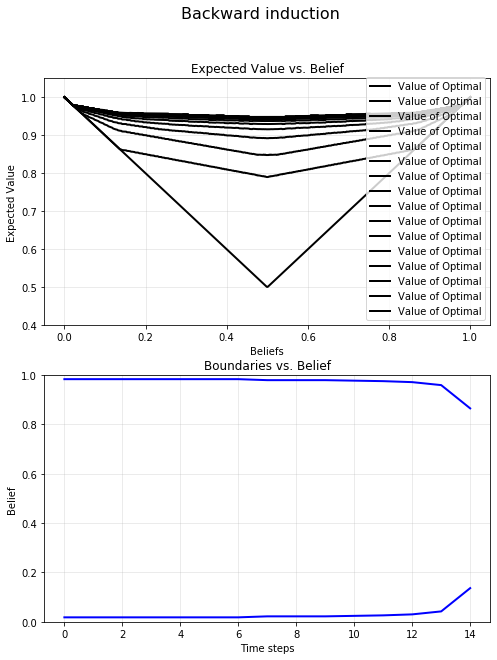

In [11]:
import matplotlib.pyplot as plt
num_belief_bins=500
beliefs = np.linspace(0, 1, num_belief_bins)
Tmax = 15
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
fig.suptitle('Backward induction', fontsize=16)

# Top Panel: Value Functions
ax1.plot(beliefs, V_optimal, 'k-', linewidth=2, label='Value of Optimal')
ax1.set_title('Expected Value vs. Belief')
ax1.set_ylabel('Expected Value')
ax1.set_xlabel('Beliefs')
ax1.set_ylim(0.4, 1.05)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
time = np.linspace(Tmax, 0, 16)
ax2.plot(bounds, 'b-', linewidth=2)
ax2.set_title('Boundaries vs. Belief')
ax2.set_xlabel('Time steps')
ax2.set_ylabel('Belief')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

# Value iteration for forward induction

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_value_iteration(P_x_H1, P_x_H2, cost, epsilon=1e-5, num_belief_bins=500):
    """
    Solves the infinite-horizon optimal stopping policy and saves an animation.
    """
    print("Starting Value Iteration...")
    
    # 1. Set up the Belief Space
    beliefs = np.linspace(0, 1, num_belief_bins)
    
    # 2. Initialize the Value function
    # V_stop is the value of deciding immediately: max(P(H1), P(H2))
    V_stop = np.maximum(beliefs, 1 - beliefs)
    V_current = np.copy(V_stop)
    
    # Storage for the animation
    V_wait_history = []
    bounds_history = []
    
    delta = float('inf')
    iteration = 0
    max_iters = 500 # Safety cap
    
    # 3. Value Iteration Loop
    while delta > epsilon and iteration < max_iters:
        V_next = np.zeros(num_belief_bins)
        V_wait_current = np.zeros(num_belief_bins)
        
        for i, b in enumerate(beliefs):
            # Marginal probability of each observation
            P_x_given_b = b * P_x_H1 + (1 - b) * P_x_H2
            
            # Bayesian update for the next belief state
            b_next = (P_x_H1 * b) / (P_x_given_b + 1e-12)
            
            # Map b_next to the discretized grid
            b_next_idx = np.clip(np.round(b_next * (num_belief_bins - 1)), 0, num_belief_bins - 1).astype(int)
            
            # Expected future value minus the cost of the sample
            expected_future_value = np.sum(P_x_given_b * V_current[b_next_idx])
            V_wait = expected_future_value - cost
            
            V_wait_current[i] = V_wait
            V_next[i] = max(V_stop[i], V_wait)
            
        # Calculate convergence delta
        delta = np.max(np.abs(V_next - V_current))
        V_current = np.copy(V_next)
        
        # Find boundaries for this iteration
        stop_action = V_stop >= (V_wait_current - 1e-9)
        lower_candidates = beliefs[(stop_action) & (beliefs <= 0.5)]
        upper_candidates = beliefs[(stop_action) & (beliefs >= 0.5)]
        
        lower_bound = np.max(lower_candidates) if len(lower_candidates) > 0 else 0.0
        upper_bound = np.min(upper_candidates) if len(upper_candidates) > 0 else 1.0
        
        # Save history for animation (save every few frames to speed up rendering)
        if iteration % 2 == 0 or delta <= epsilon:
            V_wait_history.append(np.copy(V_wait_current))
            bounds_history.append((lower_bound, upper_bound))
            
        iteration += 1

    print(f"Converged in {iteration} iterations.")
    
    # --- 4. Create the Animation ---
    print("Generating animation...")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
    fig.suptitle('Value Iteration Convergence', fontsize=16)
    
    # Top Panel: Value Functions
    ax1.plot(beliefs, V_stop, 'k-', linewidth=2, label='Value of Stopping (Deciding)')
    line_wait, = ax1.plot(beliefs, V_wait_history[0], 'b-', linewidth=2, label='Value of Waiting')
    ax1.set_title('Expected Value vs. Belief')
    ax1.set_ylabel('Expected Value')
    ax1.set_ylim(0.4, 1.05)
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # Bottom Panel: Boundary Evolution
    ax2.set_xlim(0, len(bounds_history))
    ax2.set_ylim(0, 1)
    ax2.set_title('Decision Boundaries per Iteration')
    ax2.set_xlabel('Algorithm Iteration (Backward from Convergence)')
    ax2.set_ylabel('Belief Threshold')
    
    line_upper, = ax2.plot([], [], 'r-', linewidth=2, label='Upper Bound (Choose A)')
    line_lower, = ax2.plot([], [], 'g-', linewidth=2, label='Lower Bound (Choose B)')
    ax2.axhline(0.5, color='k', linestyle='--', alpha=0.5)
    ax2.legend(loc='center right')
    ax2.grid(True, alpha=0.3)
    
    x_data = list(range(len(bounds_history)))
    upper_data = [b[1] for b in bounds_history]
    lower_data = [b[0] for b in bounds_history]
    
    def update(frame):
        # Update V_wait curve
        line_wait.set_ydata(V_wait_history[frame])
        
        # Update boundary lines up to the current frame
        line_upper.set_data(x_data[:frame+1], upper_data[:frame+1])
        line_lower.set_data(x_data[:frame+1], lower_data[:frame+1])
        
        return line_wait, line_upper, line_lower

    anim = FuncAnimation(fig, update, frames=len(bounds_history), interval=100, blit=True)
    
    # Save the animation
    filename = 'value_iteration_boundaries.gif'
    anim.save(filename, writer='pillow')
    print(f"Animation saved as '{filename}'!")
    plt.close()

# --- Run the Simulation ---
# Synthetic 5-stimulus discrete distribution
P_x_H1 = np.array([0.50, 0.25, 0.15, 0.08, 0.02])
P_x_H2 = np.array([0.02, 0.08, 0.15, 0.25, 0.50])
cost = 0.005 # Cost per sample

animate_value_iteration(P_x_H1, P_x_H2, cost)

Starting Value Iteration...
Converged in 17 iterations.
Generating animation...
Animation saved as 'value_iteration_boundaries.gif'!


In [14]:
# Forward induction by comparison only on V_stop

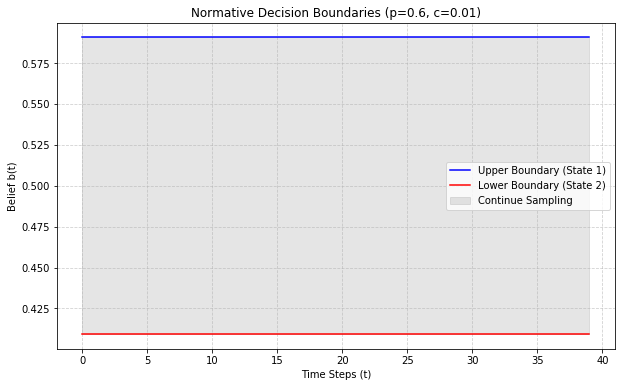

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def derive_boundaries(R=10, c=0.5, p=0.7, T_max=50, resolution=1000):
    """
    Derives decision boundaries by comparing V_stop(t) and expected V_stop(t+1).
    """
    # Belief space from 0 to 1
    beliefs = np.linspace(0, 1, resolution)
    
    # Likelihoods for discrete evidence (+1 or -1)
    # p is P(s=+1 | state 1), 1-p is P(s=+1 | state 2)
    
    upper_boundary = []
    lower_boundary = []

    for t in range(T_max):
        current_v_stop = np.maximum(beliefs, 1 - beliefs) * R - (c * t)
        
        # Calculate expected V_stop at t+1
        # 1. Probability of observing s=+1 given current belief b
        # P(s=1) = P(s=1|st1)P(st1) + P(s=1|st2)P(st2)
        p_obs_pos = beliefs *    + (1 - beliefs) * (1 - p)
        p_obs_neg = 1 - p_obs_pos
        
        # 2. Posterior beliefs after observing +1 or -1
        b_pos = (beliefs * p) / p_obs_pos
        b_neg = (beliefs * (1 - p)) / p_obs_neg
        
        # 3. V_stop at t+1 for those new beliefs
        v_stop_next_pos = np.maximum(b_pos, 1 - b_pos) * R - (c * (t + 1))
        v_stop_next_neg = np.maximum(b_neg, 1 - b_neg) * R - (c * (t + 1))
        
        expected_v_next = (p_obs_pos * v_stop_next_pos) + (p_obs_neg * v_stop_next_neg)
        
        # Stopping condition: V_stop(t) >= E[V_stop(t+1)]
        stop_mask = current_v_stop >= expected_v_next
        
        # Find the points where the mask transitions (the boundaries)
        indices = np.where(stop_mask)[0]
        if len(indices) > 0:
            # We assume symmetry, taking the highest and lowest "stop" points
            lower_boundary.append(beliefs[indices[indices < resolution // 2][-1]] if any(indices < resolution // 2) else np.nan)
            upper_boundary.append(beliefs[indices[indices >= resolution // 2][0]] if any(indices >= resolution // 2) else np.nan)
        else:
            lower_boundary.append(np.nan)
            upper_boundary.append(np.nan)

    return np.array(upper_boundary), np.array(lower_boundary)

# Parameters
R_val = 1.0   # Reward
c_val = 0.01  # Cost per step
p_val = 0.6   # Evidence strength (0.5 is random)
T_limit = 40

upper, lower = derive_boundaries(R=R_val, c=c_val, p=p_val, T_max=T_limit)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(upper, 'b-', label='Upper Boundary (State 1)')
plt.plot(lower, 'r-', label='Lower Boundary (State 2)')
plt.fill_between(range(T_limit), lower, upper, color='gray', alpha=0.2, label='Continue Sampling')
plt.title(f"Normative Decision Boundaries (p={p_val}, c={c_val})")
plt.xlabel("Time Steps (t)")
plt.ylabel("Belief b(t)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()